In [1]:
import numpy as np
import matplotlib.pyplot as plt
from update_utils import *
from retraction_free import *
from RDGD_tracking import *
from ret_free_destiny import *
from ret_deepca import *
import time

In [2]:
N = 20
m = 100
# number of samples 
n = 100
# problem dim
# n_r_ratio = 100
# r = int(n/n_r_ratio)
r = 5
# r = int(n/2)
eig_rank = int(n/2)
# rank
# max_iter = 10000

exp_num = 1
# number of experiments

In [3]:

# print(x_0.shape)
# print(X_0.shape)

A = data_gen_pca(N, n, m)/np.sqrt(m)
# A = data_gen_pca(N, n, m)/m
B = np.zeros((m*N, n))
for i in range(N):
    B[m*i:m+m*i] = A[i].T
print(np.linalg.norm(A))
print(np.linalg.norm(B))

U, S, V = np.linalg.svd(B, full_matrices=False)
print(U.shape, S.shape, V.shape)
for i in range(n):
    if eig_rank >= i:
    # if True:
        S[i] = S[0] * 0.9**(i)
    else:
        S[i] = 0
B = U@np.diag(S)@V
print(np.linalg.norm(B))

for i in range(N):
    A[i] = B[m*i:m+m*i,:].T
    
A_m = np.zeros((n,n))
for i in range(N):
    A_m += A[i]@A[i].T
    


44.640748188619284
44.640748188619284
(2000, 100) (100,) (100, 100)
12.417593375200322


In [4]:


x_opt, s, v = np.linalg.svd(A_m)
# plt.plot(s)
# x_opt = x_opt[:,:r]
x_opt = x_opt[:, :r]

# print(x_opt.T@x_opt)
print(x_opt.shape)
print(x_opt[0])

print(np.sum(np.sum(x_opt.T@A_m@x_opt)))


(100, 5)
[-0.06025209 -0.01533649  0.00841466 -0.01370293  0.08045875]
100.4337472825708


In [14]:

x_0 = np.random.randn(n, r)
x_0, _ = np.linalg.qr(x_0)


X_0 = np.repeat(x_0[np.newaxis], N, axis=0)

lin_term = None
step_size = .01


In [15]:

max_iter=10000
# max_iter=50000
distances = []
con_errors = []
grad_norms = []
x_bars = []
labels = []
time_methods = [time.time()]


In [16]:
graph_weight = 0.1



W = np.eye(N)
for i in range(N):
    W[i, i] -= 2* graph_weight
    W[i, (i-1)%N] += graph_weight
    W[i, (i+1)%N] += graph_weight
    
    
distance1, con_error1, grad_norm1, x_bar1 = ret_free_tracking(A, W, step_size, X_0, x_opt, max_iter=max_iter, lin_term=lin_term, lambd=.1)
time_methods.append(time.time() - sum(time_methods))
labels.append("1-Neighborhood")
distances.append(distance1)
con_errors.append(con_error1)
grad_norms.append(grad_norm1)
x_bars.append(x_bar1)


W = np.eye(N)
for i in range(N):
    W[i, i] -= 4* graph_weight
    W[i, (i-1)%N] += graph_weight
    W[i, (i-2)%N] += graph_weight
    W[i, (i+2)%N] += graph_weight
    W[i, (i+1)%N] += graph_weight
    
    
distance1, con_error1, grad_norm1, x_bar1 = ret_free_tracking(A, W, step_size, X_0, x_opt, max_iter=max_iter, lin_term=lin_term, lambd=.1)
time_methods.append(time.time() - sum(time_methods))
labels.append("2-Neighborhood")
distances.append(distance1)
con_errors.append(con_error1)
grad_norms.append(grad_norm1)
x_bars.append(x_bar1)

W = np.eye(N)
for i in range(N):
    W[i, i] -= 8* graph_weight
    W[i, (i-1)%N] += graph_weight
    W[i, (i-2)%N] += graph_weight
    W[i, (i-3)%N] += graph_weight
    W[i, (i-4)%N] += graph_weight
    W[i, (i-5)%N] += graph_weight
    W[i, (i+1)%N] += graph_weight
    W[i, (i+2)%N] += graph_weight
    W[i, (i+3)%N] += graph_weight
    W[i, (i+4)%N] += graph_weight
    W[i, (i+5)%N] += graph_weight
    
    
distance1, con_error1, grad_norm1, x_bar1 = ret_free_tracking(A, W, step_size, X_0, x_opt, max_iter=max_iter, lin_term=lin_term, lambd=.1)
time_methods.append(time.time() - sum(time_methods))
labels.append("5-Neighborhood")
distances.append(distance1)
con_errors.append(con_error1)
grad_norms.append(grad_norm1)
x_bars.append(x_bar1)


W = np.ones((N, N))/N
# for i in range(N):
#     W[i, i] -= 4* graph_weight
#     W[i, (i-1)%N] += graph_weight
#     W[i, (i-2)%N] += graph_weight
#     W[i, (i+2)%N] += graph_weight
#     W[i, (i+1)%N] += graph_weight
    
    
distance1, con_error1, grad_norm1, x_bar1 = ret_free_tracking(A, W, step_size, X_0, x_opt, max_iter=max_iter, lin_term=lin_term, lambd=.1)
time_methods.append(time.time() - sum(time_methods))
labels.append("10-Neighborhood")
distances.append(distance1)
con_errors.append(con_error1)
grad_norms.append(grad_norm1)
x_bars.append(x_bar1)

  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [00:33<00:00, 295.27it/s]


total time: 33.873791217803955
retraction_time time: 0
communication_time time: 20.646435260772705
gradient time: 10.407728672027588
logging_time time: 2.182203531265259


100%|██████████| 10000/10000 [00:33<00:00, 302.28it/s]


total time: 33.08511400222778
retraction_time time: 0
communication_time time: 20.22069525718689
gradient time: 10.13611650466919
logging_time time: 2.1336822509765625


100%|██████████| 10000/10000 [00:33<00:00, 301.77it/s]


total time: 33.14095115661621
retraction_time time: 0
communication_time time: 20.211592197418213
gradient time: 10.178649425506592
logging_time time: 2.1477649211883545


100%|██████████| 10000/10000 [00:32<00:00, 303.16it/s]

total time: 32.98942708969116
retraction_time time: 0
communication_time time: 20.092023134231567
gradient time: 10.189298868179321
logging_time time: 2.103672742843628


In [17]:
save_data = {
    'labels' : labels,
    'distances': distances,
    'con_errors': con_errors, 
    'grad_norms': grad_norms,
    'x_bars': x_bars
    }
import pickle

file = open('save_data_graph', 'ab')
pickle.dump(save_data, file)
file.close()

<Figure size 640x480 with 0 Axes>

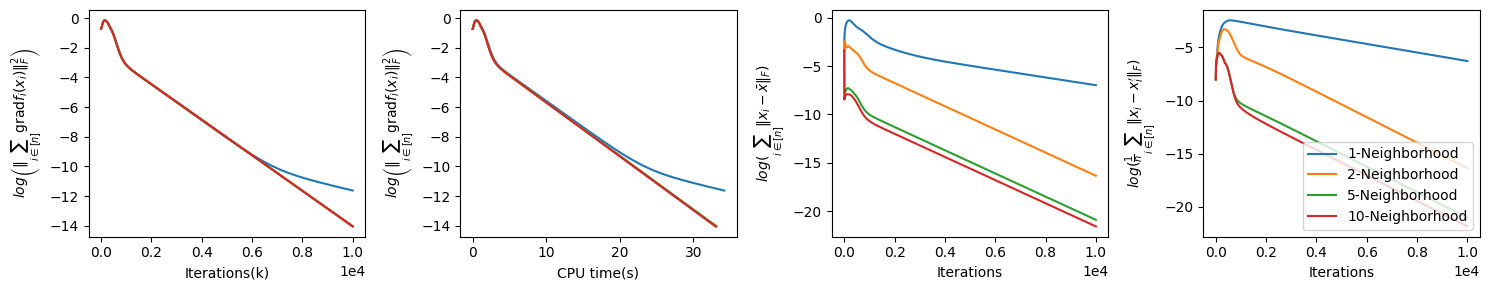

In [ ]:


# label1 = "DRFGT (This paper)"
# # label2 = "DRGTA (Chen et al. 2021a)"
# label2 = "DESTINY"
# labels = [
#     "DRFGT (This paper)",
#     "DESTINY",
#     "DRGTA",
# ]
import matplotlib.pyplot as plt

plt.rcParams['text.usetex'] = False
plt.tight_layout()

f, ((ax1, ax2, ax3, ax4)) = plt.subplots(1,4, figsize=(15,3))


for i in range(len(labels)):
    # if labels[i] == "DESTINY":
    #     continue
    if labels[i] == "DeEPCA":
        continue
        comm_step = 30
        ax1.plot(np.linspace(0, comm_step * grad_norms[i].shape[0], grad_norms[i].shape[0]), 
                 np.log(grad_norms[i]), label=labels[i])
        ax2.plot(np.linspace(0, comm_step *time_methods[i+1], grad_norms[i].shape[0]), 
                np.log(grad_norms[i]), label=labels[i])
        ax3.plot(np.linspace(0, comm_step * grad_norms[i].shape[0], grad_norms[i].shape[0]), 
                 np.log(con_errors[i]), label=labels[i])
        ax4.plot(np.linspace(0, comm_step * grad_norms[i].shape[0], grad_norms[i].shape[0]), 
                 np.log(distances[i]), label=labels[i])
    else:
        ax1.plot(np.log(grad_norms[i]), label=labels[i])
        ax2.plot(np.linspace(0, time_methods[i+1], grad_norms[i].shape[0]), 
                np.log(grad_norms[i]), label=labels[i])
        ax3.plot(np.log(con_errors[i]), label=labels[i])
        ax4.plot(np.log(distances[i]), label=labels[i])
        # ax1.plot((grad_norms[i]), label=labels[i])
        # ax2.plot(np.linspace(0, time_methods[i+1], grad_norms[i].shape[0]), 
        #         (grad_norms[i]), label=labels[i])
        # ax3.plot((con_errors[i]), label=labels[i])
        # ax4.plot((distances[i]), label=labels[i])


# ax1.set_ylabel("Gradient Norm")
# ax1.set_ylabel(r"$log(\|\nabla F( \bar{x} )\|_F^2)$")
# ax1.set_ylabel(r"$log(\text{Grad Norm})$")
ax1.set_ylabel(r"$log \left(\|\sum_{i\in [n]} \text{grad} f_i(x_i) \|^2_F \right)$")

ax1.set_xlabel("Iterations(k)")
# ax1.legend()

ax2.set_ylabel(r"$log(\|\nabla F( \bar{x} )\|_F^2)$")
ax2.set_ylabel(r"$log \left(\|\sum_{i\in [n]} \text{grad} f_i(x_i) \|^2_F \right)$")

# ax2.set_ylabel("Gradient Norm")
ax2.set_xlabel("CPU time(s)")

# ax2.set_title("Elapsed Time")
# ax2.legend()


ax3.set_ylabel("Consensus error")
ax3.set_ylabel(r"$log(  \sum_{i\in [n]}\|x_i - \bar{x}\|_F )$")

ax3.set_xlabel("Iterations")
# ax3.legend()


ax4.set_ylabel("Average distance to $\\mathcal{M}$")
ax4.set_ylabel(r"$log( \frac{1}{n}\sum_{i\in [n]} \|x_i - x_i'\|_F )$")
ax4.set_xlabel("Iterations")
# ax4.set_ylim(-10,5)
# ax1.set_xlim(0,2000)
# # ax2.set_xlim(0,10)
# ax3.set_xlim(0,2000)
# ax4.set_xlim(0,1000)
# ax4.set_title("distance")
ax4.legend(loc=4)
ax4.ticklabel_format(axis='x', style='sci', scilimits=(0,0))
ax1.ticklabel_format(axis='x', style='sci', scilimits=(0,0))
ax3.ticklabel_format(axis='x', style='sci', scilimits=(0,0))

plt.tight_layout()
plt.ticklabel_format(axis='x', style='sci')
# plt.savefig("graph_compare.pdf")

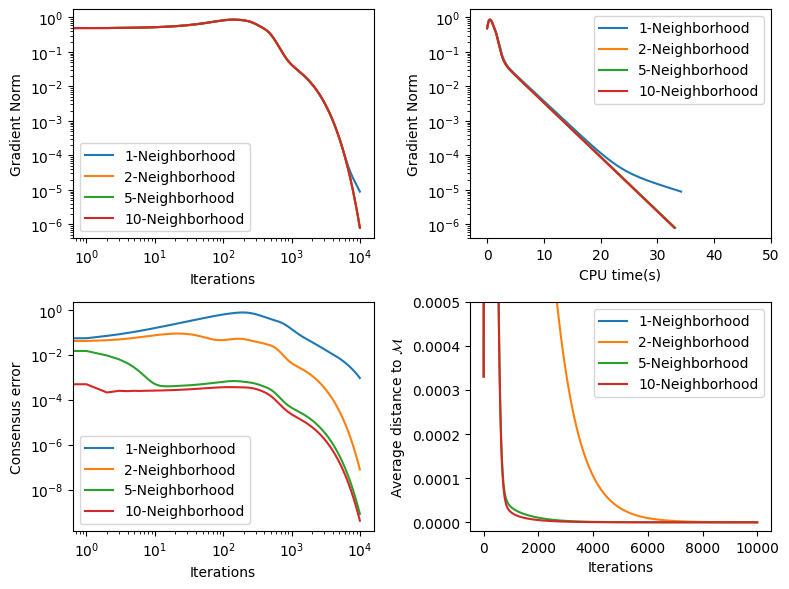

In [19]:
# label1 = "DRFGT (This paper)"
# # label2 = "DRGTA (Chen et al. 2021a)"
# label2 = "DESTINY"
# labels = [
#     "DRFGT (This paper)",
#     "DESTINY",
#     "DRGTA",
# ]

# f, ((ax1, ax2, ax3, ax4)) = plt.subplots(1,4, figsize=(20,4))
f, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize=(8,6))


for i in range(len(labels)):
    # if labels[i] == "DESTINY":
    #     continue
    if labels[i] == "DeEPCA":
        continue
        comm_step = 30
        ax1.plot(np.linspace(0, comm_step * grad_norms[i].shape[0], grad_norms[i].shape[0]), 
                 np.log(grad_norms[i]), label=labels[i])
        ax2.plot(np.linspace(0, comm_step *time_methods[i+1], grad_norms[i].shape[0]), 
                np.log(grad_norms[i]), label=labels[i])
        ax3.plot(np.linspace(0, comm_step * grad_norms[i].shape[0], grad_norms[i].shape[0]), 
                 np.log(con_errors[i]), label=labels[i])
        ax4.plot(np.linspace(0, comm_step * grad_norms[i].shape[0], grad_norms[i].shape[0]), 
                 np.log(distances[i]), label=labels[i])
    else:
        ax1.plot((grad_norms[i]), label=labels[i])
        ax2.plot(np.linspace(0, time_methods[i+1], grad_norms[i].shape[0]), 
                (grad_norms[i]), label=labels[i])
        ax3.plot((con_errors[i]), label=labels[i])
        ax4.plot((distances[i]), label=labels[i])
        # ax1.plot((grad_norms[i]), label=labels[i])
        # ax2.plot(np.linspace(0, time_methods[i+1], grad_norms[i].shape[0]), 
        #         (grad_norms[i]), label=labels[i])
        # ax3.plot((con_errors[i]), label=labels[i])
        # ax4.plot((distances[i]), label=labels[i])


ax1.set_ylabel("Gradient Norm")
ax1.set_xlabel("Iterations")
ax1.legend()
ax1.set_xscale('log')
ax1.set_yscale('log')

ax2.set_ylabel("Gradient Norm")
ax2.set_xlabel("CPU time(s)")

# ax2.set_title("Elapsed Time")
ax2.legend()
ax2.set_xlim(-3,50)
ax2.set_yscale('log')


ax3.set_ylabel("Consensus error")
ax3.set_xlabel("Iterations")
ax3.legend()
ax3.set_xscale('log')
ax3.set_yscale('log')

ax4.set_ylabel("Average distance to $\\mathcal{M}$")
ax4.set_xlabel("Iterations")
ax4.set_ylim(-2e-5, 5e-4)
# ax1.set_xlim(0,2000)
# # ax2.set_xlim(0,10)
# ax3.set_xlim(0,2000)
# ax4.set_xlim(0,1000)
# ax4.set_title("distance")
ax4.legend()
# ax4.set_xscale('log')
# ax4.set_yscale('log')
f.tight_layout()
# plt.savefig("Procrustes_quad_lin4.pdf")

In [19]:

# ax1.set_title('Sharing Y axis')
# ax2.scatter(x, y)
# plt.savefig("methods_compare_d"+str(n)+"r"+str(r)+"N"+str(N)+".pdf")

In [20]:

# plt.plot(np.log(distance1), label='gradient tracking')
# plt.plot(np.log(distance2), label='RDGD')


# print(np.sum(np.sum(x_opt.T@A_m@x_opt)))
# print(np.sum(np.sum(x_bar1.T@A_m@x_bar1)))
# # print(np.sum(np.sum(x_bar2.T@A_m@x_bar2)))
# plt.title("distance")
# plt.legend()

In [21]:

# plt.plot(np.log(grad_norm1), label='gradient tracking')
# plt.plot(np.log(grad_norm2), label='RDGD')


# plt.title("avg grad norm")
# plt.legend()

In [22]:

# plt.plot(np.log(con_error1), label='gradient tracking')
# plt.plot(np.log(con_error2), label='RDGD')

# plt.title("consensus error")
# plt.legend()

In [23]:
# label1 = "DRFGT (This paper)"
# label2 = "DRGTA (Chen et al. 2021a)"
# labels = [
#     "DRFGT (This paper)",
#     "DESTINY",
#     # "DRGTA (Chen et al. 2021a)",
#     "DRGTA",
# ]

# f, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize=(10,6))


# ax1.plot(np.log(grad_norm1), label=label1)
# ax1.plot(np.log(grad_norm2), label=label2)
# ax1.set_ylabel("Gradient Norm")
# ax1.set_xlabel("Iterations")
# # ax1.set_title("Optimality")
# ax1.legend()

# ax2.plot(np.linspace(0, time1, grad_norm1.shape[0]), np.log(grad_norm1), label=label1)
# ax2.plot(np.linspace(0, time2, grad_norm2.shape[0]), np.log(grad_norm2), label=label2)
# # ax2.set_ylabel("$\sum_{i\in [n]}\\text{grad} f_i(x_i)$")
# ax2.set_ylabel("Gradient Norm")
# ax2.set_xlabel("CPU time(s)")

# # ax2.set_title("Elapsed Time")
# ax2.legend()


# ax3.plot(np.log(con_error1), label=label1)
# ax3.plot(np.log(con_error2), label=label2)
# ax3.set_ylabel("Consensus error")
# ax3.set_xlabel("Iterations")
# ax3.legend()



# ax4.plot(np.log(distance1), label=label1)
# ax4.plot(np.log(distance2), label=label2)
# ax4.set_ylabel("Average distance to $\\mathcal{M}$")
# ax4.set_xlabel("Iterations")
# # ax4.set_title("distance")
# ax4.legend()


# # ax1.set_title('Sharing Y axis')
# # ax2.scatter(x, y)
# # plt.savefig("quad_compare.pdf")

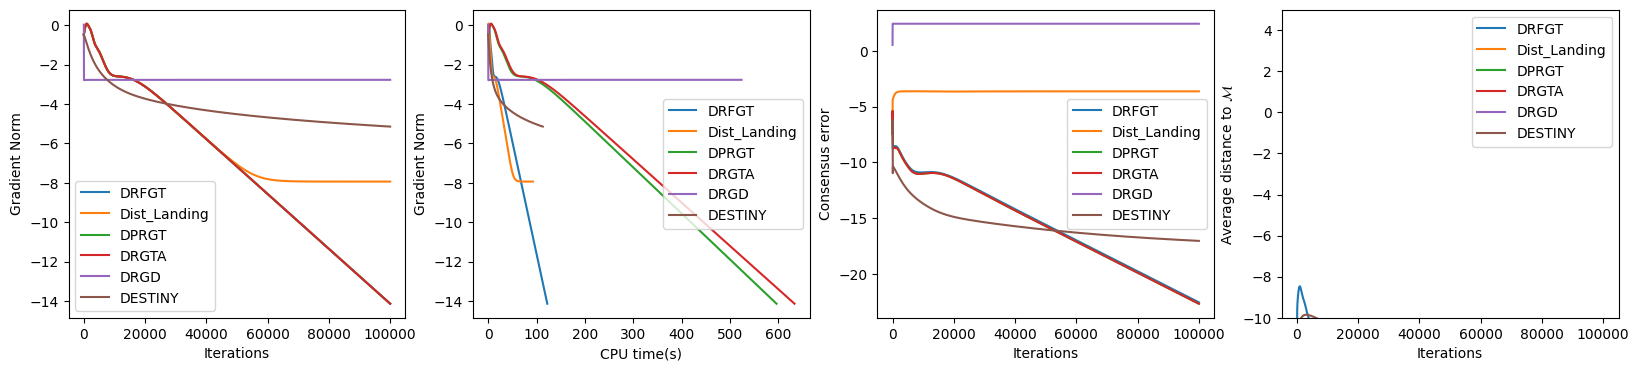

In [24]:
# label1 = "DRFGT (This paper)"
# # label2 = "DRGTA (Chen et al. 2021a)"
# label2 = "DESTINY"
# labels = [
#     "DRFGT (This paper)",
#     "DESTINY",
#     "DRGTA",
# ]

f, ((ax1, ax2, ax3, ax4)) = plt.subplots(1,4, figsize=(20,4))


for i in range(len(labels)):
    if labels[i] == "DeEPCA":
        comm_step = 1
        ax1.plot(np.linspace(0, comm_step * grad_norms[i].shape[0], grad_norms[i].shape[0]), 
                 np.log(grad_norms[i]), label=labels[i])
        ax2.plot(np.linspace(0, comm_step *time_methods[i+1], grad_norms[i].shape[0]), 
                np.log(grad_norms[i]), label=labels[i])
        ax3.plot(np.linspace(0, comm_step * grad_norms[i].shape[0], grad_norms[i].shape[0]), 
                 np.log(con_errors[i]), label=labels[i])
        ax4.plot(np.linspace(0, comm_step * grad_norms[i].shape[0], grad_norms[i].shape[0]), 
                 np.log(distances[i]), label=labels[i])
    else:
        ax1.plot(np.log(grad_norms[i]), label=labels[i])
        ax2.plot(np.linspace(0, time_methods[i+1], grad_norms[i].shape[0]), 
                np.log(grad_norms[i]), label=labels[i])
        ax3.plot(np.log(con_errors[i]), label=labels[i])
        ax4.plot(np.log(distances[i]), label=labels[i])



# ax1.plot(np.log(grad_norm1), label=label1)
# ax1.plot(np.log(grad_norm2), label=label2)
ax1.set_ylabel("Gradient Norm")
ax1.set_xlabel("Iterations")
# ax1.set_title("Optimality")
ax1.legend()

# ax2.plot(np.linspace(0, time1, grad_norm1.shape[0]), np.log(grad_norm1), label=label1)
# ax2.plot(np.linspace(0, time2, grad_norm2.shape[0]), np.log(grad_norm2), label=label2)
# ax2.set_ylabel("$\sum_{i\in [n]}\\text{grad} f_i(x_i)$")
ax2.set_ylabel("Gradient Norm")
ax2.set_xlabel("CPU time(s)")

# ax2.set_title("Elapsed Time")
ax2.legend()


# ax3.plot(np.log(con_error1), label=label1)
# ax3.plot(np.log(con_error2), label=label2)
ax3.set_ylabel("Consensus error")
ax3.set_xlabel("Iterations")
ax3.legend()



# ax4.plot(np.log(distance1), label=label1)
# ax4.plot(np.log(distance2), label=label2)
ax4.set_ylabel("Average distance to $\\mathcal{M}$")
ax4.set_xlabel("Iterations")
ax4.set_ylim(-10,5)
# ax1.set_xlim(0,2000)
# # ax2.set_xlim(0,10)
# ax3.set_xlim(0,2000)
# ax4.set_xlim(0,1000)
# ax4.set_title("distance")
ax4.legend()


# ax1.set_title('Sharing Y axis')
# ax2.scatter(x, y)
# plt.savefig("methods_compare_d"+str(n)+"r"+str(r)+"N"+str(N)+".pdf")

NameError: name 'con_error2' is not defined

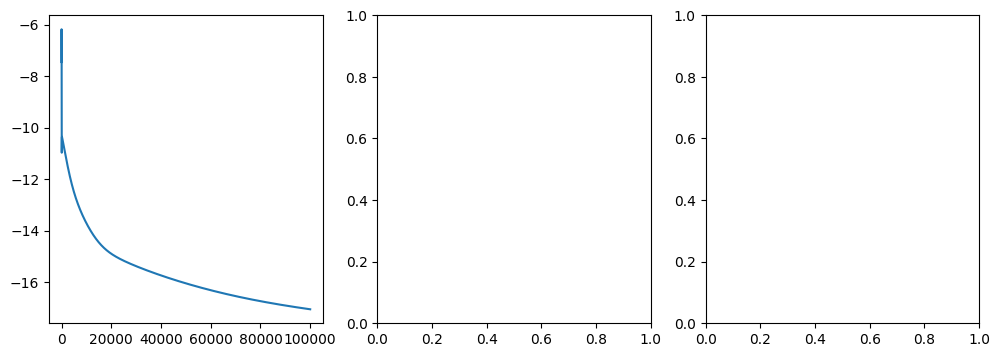

In [25]:
f, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(12,4))
ax1.plot(np.log(con_error1), label='gradient tracking')
ax1.plot(np.log(con_error2), label='RDGD')

ax1.set_title("consensus error")
ax1.legend()


ax2.plot(np.log(grad_norm1), label='gradient tracking')
ax2.plot(np.log(grad_norm2), label='RDGD')
ax2.set_title("avg grad norm")
ax2.legend()

ax3.plot(np.log(distance1), label='gradient tracking')
ax3.plot(np.log(distance2), label='RDGD')
ax3.set_title("distance")
ax3.legend()


# ax1.set_title('Sharing Y axis')
# ax2.scatter(x, y)

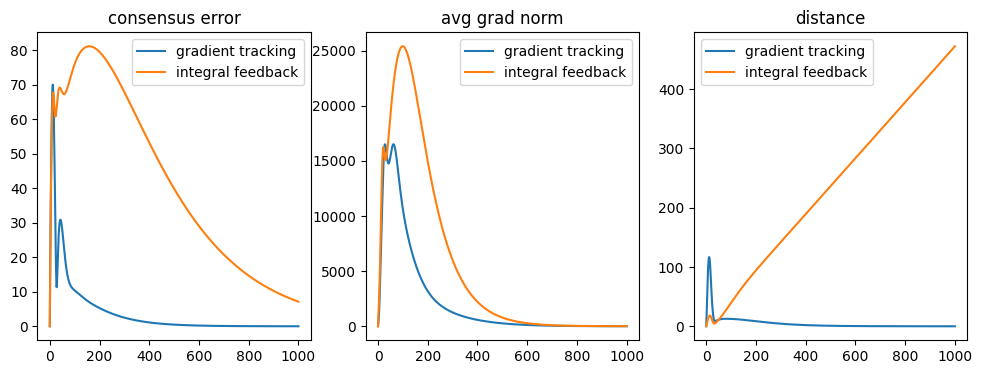

In [ ]:
# len = distance1.shape[0]
# k_range = np.linspace(0,distance1.shape[0], distance1.shape[0])
# # print(k_range.shape)
# # print(distance1.shape)
# # plt.plot(k_range, distance1*k_range)

# # plt.plot(k_range, distance2*k_range)

# # plt.ylim(0, 100)

# f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))
# ax1.plot(k_range, con_error1[:len]*k_range, label='gradient tracking')
# ax1.plot(k_range, (con_error2[:len])*k_range, label='integral feedback')

# ax1.set_title("consensus error")
# ax1.legend()


# ax2.plot(k_range, (grad_norm1[:len])*k_range, label='gradient tracking')
# ax2.plot(k_range, (grad_norm2[:len])*k_range, label='integral feedback')
# ax2.set_title("avg grad norm")
# ax2.legend()

# ax3.plot(k_range, (distance1[:len])*k_range, label='gradient tracking')
# ax3.plot(k_range, (distance2[:len])*k_range, label='integral feedback')
# ax3.set_title("distance")
# ax3.legend()